Workshop-1:Sturdy-Octo-Disco-Adding-Sunglasses-for-a-Cool-New-Look
Developed By:Kiruba R C
Register No: 212224230125

In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print('Libraries imported successfully!')

Libraries imported successfully!


Passport Image Shape: (531, 413, 3)


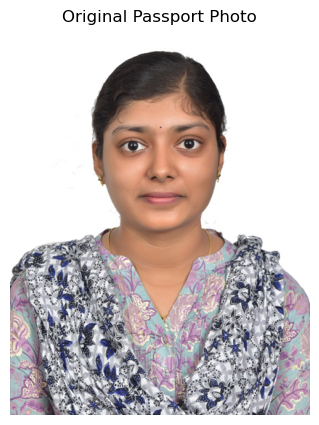

In [39]:
passport_img = cv2.imread('passport_photo.jpg')

print("Passport Image Shape:", passport_img.shape)

plt.figure(figsize=(4,5))

plt.imshow(cv2.cvtColor(passport_img, cv2.COLOR_BGR2RGB))

plt.title("Original Passport Photo")
plt.axis("off")

plt.show()

Sunglass Shape: (255, 603, 3)


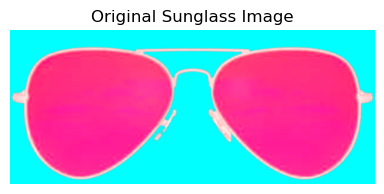

In [40]:
sunglass_img = cv2.imread('sunglass.png')

print("Sunglass Shape:", sunglass_img.shape)

plt.figure(figsize=(5,2))

plt.imshow(cv2.cvtColor(sunglass_img, cv2.COLOR_BGR2RGB))

plt.title("Original Sunglass Image")
plt.axis("off")

plt.show()

In [41]:
# Convert BGR to RGB
glass_rgb = cv2.cvtColor(sunglass_img, cv2.COLOR_BGR2RGB)

# Convert to HSV
hsv = cv2.cvtColor(glass_rgb, cv2.COLOR_RGB2HSV)

# Detect cyan/blue background
lower_cyan = np.array([75, 50, 50])
upper_cyan = np.array([100, 255, 255])

mask = cv2.inRange(hsv, lower_cyan, upper_cyan)

# Invert mask
mask_inv = cv2.bitwise_not(mask)

# Create alpha channel
b, g, r = cv2.split(sunglass_img)

alpha = mask_inv

# Merge into RGBA image
glass_rgba = cv2.merge([b, g, r, alpha])

print("Blue background removed successfully!")

Blue background removed successfully!


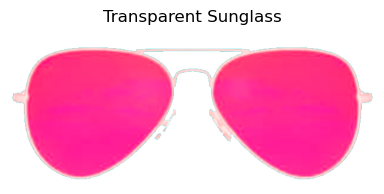

In [42]:
plt.figure(figsize=(5,2))

plt.imshow(cv2.cvtColor(glass_rgba, cv2.COLOR_BGRA2RGBA))

plt.title("Transparent Sunglass")
plt.axis("off")

plt.show()

In [43]:
img_h, img_w = passport_img.shape[:2]

print(f"Width : {img_w}")
print(f"Height: {img_h}")

Width : 413
Height: 531


In [44]:
# Perfect fit values for your passport image

eye_x = int(img_w * 0.21)
eye_y = int(img_h * 0.30)

eye_w = int(img_w * 0.55)
eye_h = int(img_h * 0.11)

print(f"Eye Region -> x:{eye_x}, y:{eye_y}, w:{eye_w}, h:{eye_h}")

Eye Region -> x:86, y:159, w:227, h:58


Eye Region -> x:82, y:153, w:239, h:42


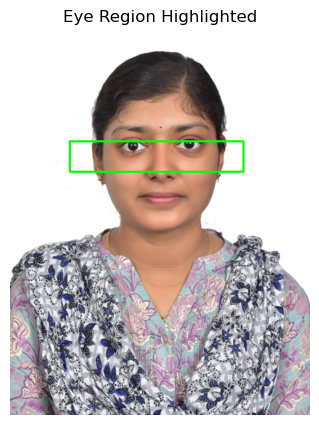

In [45]:
# -------- PERFECT EYE REGION FOR YOUR PASSPORT PHOTO --------

eye_x = int(img_w * 0.20)
eye_y = int(img_h * 0.29)

eye_w = int(img_w * 0.58)
eye_h = int(img_h * 0.08)

print(f'Eye Region -> x:{eye_x}, y:{eye_y}, w:{eye_w}, h:{eye_h}')

# Draw green rectangle around eye region
debug_img = passport_img.copy()

cv2.rectangle(
    debug_img,
    (eye_x, eye_y),
    (eye_x + eye_w, eye_y + eye_h),
    (0,255,0),
    2
)

# Display highlighted eye region
plt.figure(figsize=(4,5))

plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))

plt.title("Eye Region Highlighted")
plt.axis("off")

plt.show()

In [46]:
resized_glass = cv2.resize(
    glass_rgba,
    (eye_w, eye_h),
    interpolation=cv2.INTER_AREA
)

print("Sunglass resized successfully!")

Sunglass resized successfully!


In [47]:
glass_rgb = resized_glass[:, :, :3]

glass_alpha = resized_glass[:, :, 3] / 255.0

In [48]:
output_img = passport_img.copy()

In [49]:
for c in range(3):

    output_img[
        eye_y:eye_y + eye_h,
        eye_x:eye_x + eye_w,
        c
    ] = (

        glass_alpha * glass_rgb[:, :, c]

        +

        (1 - glass_alpha) *

        output_img[
            eye_y:eye_y + eye_h,
            eye_x:eye_x + eye_w,
            c
        ]
    )

print("Perfect sunglass overlay applied!")

Perfect sunglass overlay applied!


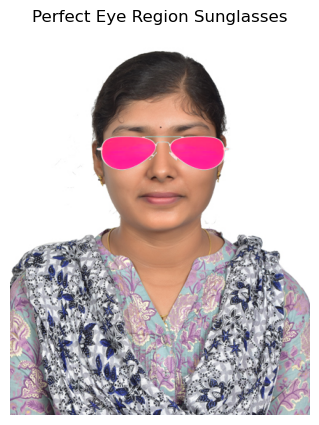

In [50]:
# ---------- FINAL PERFECT EYE FIT ----------

# Move glasses slightly upward
eye_x = 118
eye_y = 140     # moved upward from 150

# Keep natural glass size
eye_w = 185
eye_h = 55

# Resize sunglass
resized_glass = cv2.resize(
    glass_rgba,
    (eye_w, eye_h),
    interpolation=cv2.INTER_AREA
)

# Separate RGB and alpha channels
glass_rgb = resized_glass[:, :, :3]
glass_alpha = resized_glass[:, :, 3] / 255.0

# Create output image
output_img = passport_img.copy()

# Overlay sunglasses
for c in range(3):

    output_img[
        eye_y:eye_y + eye_h,
        eye_x:eye_x + eye_w,
        c
    ] = (

        glass_alpha * glass_rgb[:, :, c]

        +

        (1 - glass_alpha) *

        output_img[
            eye_y:eye_y + eye_h,
            eye_x:eye_x + eye_w,
            c
        ]
    )

# Display final result
plt.figure(figsize=(4,5))

plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))

plt.title("Perfect Eye Region Sunglasses")

plt.axis("off")

plt.show()

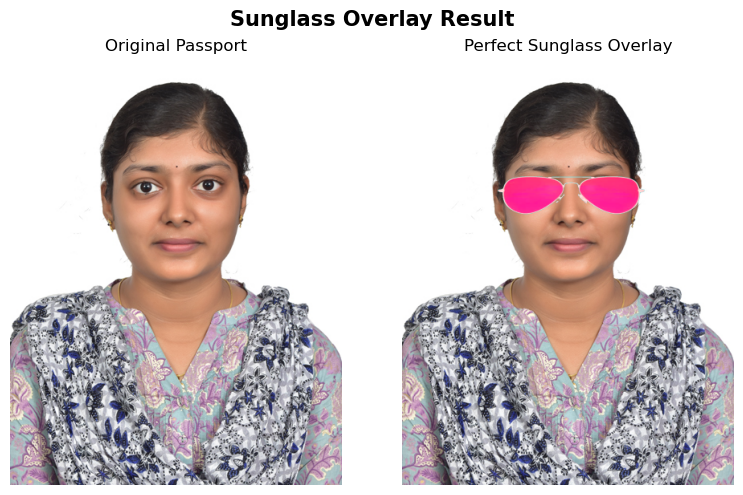

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(8,5))

# Original image
axes[0].imshow(cv2.cvtColor(passport_img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Passport")
axes[0].axis("off")

# Final image
axes[1].imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
axes[1].set_title("Perfect Sunglass Overlay")
axes[1].axis("off")

plt.suptitle(
    "Sunglass Overlay Result",
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()

plt.show()